In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split

In [2]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

Diagnosis
B            357
M            212
Name: count, dtype: int64


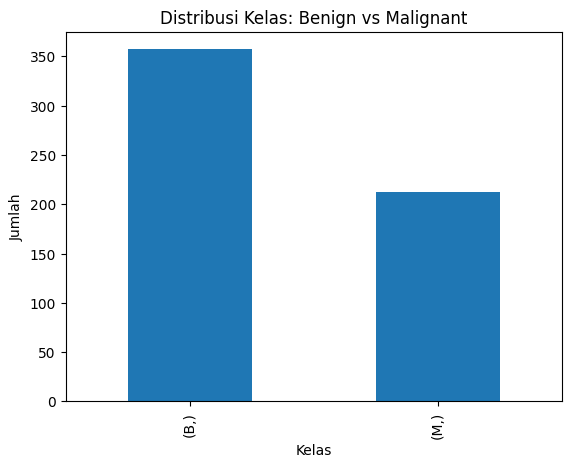

In [3]:
print(y.value_counts())
y.value_counts().plot(kind='bar')
plt.title("Distribusi Kelas: Benign vs Malignant")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()


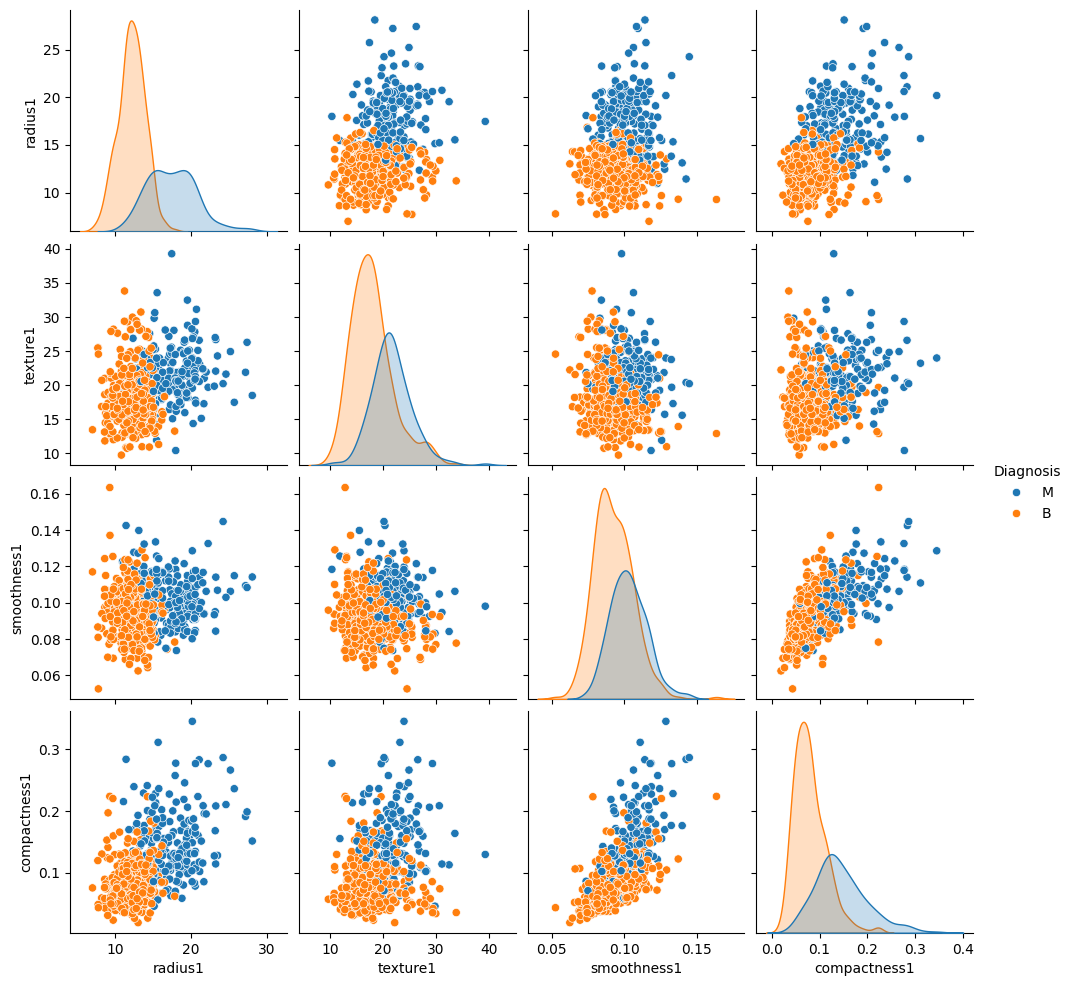

In [4]:
df = X.copy()
df['Diagnosis'] = y
# Visualisasi hubungan antar fitur
sns.pairplot(df[['radius1', 'texture1', 'smoothness1', 'compactness1', 'Diagnosis']], hue='Diagnosis')
plt.show()

Visualisasi pairplot di atas menunjukkan hubungan antara beberapa fitur dalam dataset kanker payudara, dengan titik-titik yang mewakili dua kelas target: benign (0) dan malignant (1). Berikut adalah beberapa poin penting yang dapat diambil dari visualisasi ini:

**Distribusi Fitur Berdasarkan Kelas**:
Radius1: Distribusi radius1 menunjukkan bahwa kelas benign (0) cenderung memiliki nilai yang lebih rendah dibandingkan dengan kelas malignant (1), di mana malignant tersebar di seluruh rentang nilai radius yang lebih tinggi.
Texture1, Smoothness1, Compactness1: Untuk fitur-fitur seperti texture1, smoothness1, dan compactness1, kita dapat mengamati bahwa kelas benign memiliki nilai yang lebih rendah, sedangkan malignant cenderung memiliki nilai yang lebih tinggi pada fitur-fitur ini. Hal ini menunjukkan bahwa tumor yang bersifat ganas cenderung memiliki tekstur, kelancaran, dan kepadatan yang lebih tinggi.

**Hubungan Antar Fitur**:
Pada plot radius1 vs texture1, terlihat adanya perbedaan yang jelas antara benign dan malignant, di mana titik-titik malignant (oranye) tersebar lebih merata pada rentang nilai yang lebih tinggi, sementara titik-titik benign (biru) lebih terkonsentrasi pada nilai lebih rendah.
Hubungan serupa terlihat pada plot radius1 vs smoothness1 dan radius1 vs compactness1, di mana kelas malignant menunjukkan nilai yang lebih tinggi pada kedua fitur ini, sementara kelas benign lebih terkonsentrasi pada rentang lebih rendah.

**Cakupan dan Variabilitas Kelas**:
Kelas malignant (oranye) menunjukkan variasi yang lebih besar dalam fitur-fitur yang diuji, dengan distribusi yang lebih tersebar, yang mengindikasikan bahwa tumor ganas memiliki keragaman yang lebih besar dalam hal ukuran, tekstur, kelancaran, dan kepadatan dibandingkan dengan tumor jinak.
Sebaliknya, kelas benign (biru) lebih terkonsentrasi pada rentang nilai tertentu, terutama untuk radius1 dan smoothness1, menunjukkan bahwa tumor jinak cenderung memiliki nilai-nilai yang lebih seragam.

**Pemisahan Kelas**:
Secara keseluruhan, meskipun ada beberapa tumpang tindih antara kelas benign dan malignant, plot ini menunjukkan bahwa ada fitur-fitur tertentu yang dapat digunakan untuk membedakan kedua kelas tersebut.
Misalnya, fitur radius1 dan compactness1 memberikan indikasi yang lebih jelas untuk membedakan antara tumor benign dan malignant, meskipun ada beberapa titik dari kelas benign yang memiliki nilai radius1 dan compactness1 yang tinggi, ini menunjukkan adanya kesulitan dalam klasifikasi pada beberapa kasus.

In [5]:
# Label Encoding
y = y['Diagnosis'].map({'B': 0, 'M': 1})

In [6]:
# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [7]:
# Scaling (Normalisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import os

# Menentukan folder tempat menyimpan file
folder_path = '../data/preprocessed_wdbc'

# Pastikan folder ada
os.makedirs(folder_path, exist_ok=True)

# Menyimpan data X_train_scaled ke CSV
X_train_scaled_df = pd.DataFrame(X_train_scaled)  
X_train_scaled_df.to_csv(os.path.join(folder_path, 'X_train.csv'), index=False)

# Menyimpan data X_test_scaled ke CSV
X_test_scaled_df = pd.DataFrame(X_test_scaled)  
X_test_scaled_df.to_csv(os.path.join(folder_path, 'X_test.csv'), index=False)

# Menyimpan labels untuk data tabular
y_train_df = pd.DataFrame(y_train)  
y_train_df.to_csv(os.path.join(folder_path, 'y_train.csv'), index=False)

y_test_df = pd.DataFrame(y_test)    
y_test_df.to_csv(os.path.join(folder_path, 'y_test.csv'), index=False)

print("Data berhasil disimpan ke dalam folder 'data/preprocessed_wdbc'.")

Data berhasil disimpan ke dalam folder 'data/preprocessed_wdbc'.
